In [15]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df = pd.read_csv(url)

treated_fips = df['stfips'].unique()[:10]
df['TREAT'] = df['stfips'].isin(treated_fips).astype(int)

In [16]:
# Interacción TWFE
df['treated'] = df['TREAT'] * df['post']

# Estimar TWFE
model_twfe = smf.ols(
    "asmrs ~ treated + pcinc + asmrh + cases + C(stfips) + C(year)",
    data=df
).fit(cov_type='cluster', cov_kwds={"groups": df["stfips"]})

print(model_twfe.summary())

                            OLS Regression Results                            
Dep. Variable:                  asmrs   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     29.03
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           1.93e-22
Time:                        09:30:07   Log-Likelihood:                -6096.6
No. Observations:                1617   AIC:                         1.236e+04
Df Residuals:                    1532   BIC:                         1.282e+04
Df Model:                          84                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          55.3929      4.292     

C:\Users\Matias\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 84, but rank is 36
  warnings.warn('covariance of constraints does not have full '


In [17]:
# Supongamos que '_nfd' indica año de tratamiento, y 0 = nunca tratado
df['treat_year'] = df['_nfd']
df.loc[df['treat_year'] == 0, 'treat_year'] = np.nan  # nunca tratados

# Tiempo relativo
df['event_time'] = df['year'] - df['treat_year']
df.loc[df['treat_year'].isna(), 'event_time'] = np.nan  # para nunca tratados

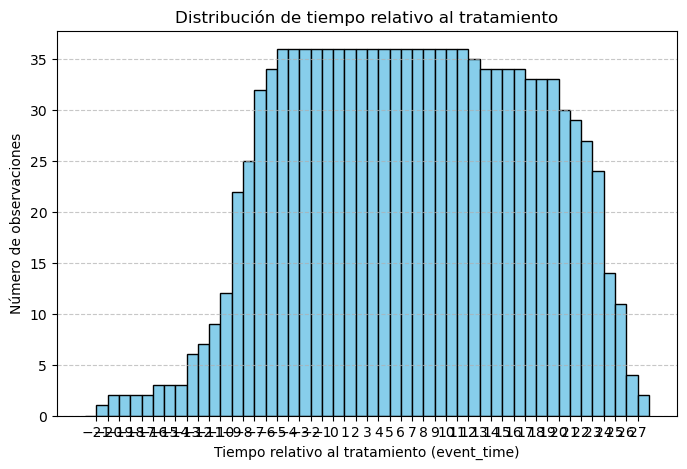

In [18]:
# Filtramos para solo incluir event_time no nulos
event_time_vals = df['event_time'].dropna()

plt.figure(figsize=(8,5))
plt.hist(event_time_vals, bins=range(int(event_time_vals.min())-1, int(event_time_vals.max())+2),
         edgecolor='black', color='skyblue')
plt.xlabel("Tiempo relativo al tratamiento (event_time)")
plt.ylabel("Número de observaciones")
plt.title("Distribución de tiempo relativo al tratamiento")
plt.xticks(range(int(event_time_vals.min()), int(event_time_vals.max())+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
event_summary = df['event_time'].value_counts().sort_index()
print(event_summary)

event_time
-21.0     1
-20.0     2
-19.0     2
-18.0     2
-17.0     2
-16.0     3
-15.0     3
-14.0     3
-13.0     6
-12.0     7
-11.0     9
-10.0    12
-9.0     22
-8.0     25
-7.0     32
-6.0     34
-5.0     36
-4.0     36
-3.0     36
-2.0     36
-1.0     36
 0.0     36
 1.0     36
 2.0     36
 3.0     36
 4.0     36
 5.0     36
 6.0     36
 7.0     36
 8.0     36
 9.0     36
 10.0    36
 11.0    36
 12.0    35
 13.0    34
 14.0    34
 15.0    34
 16.0    34
 17.0    33
 18.0    33
 19.0    33
 20.0    30
 21.0    29
 22.0    27
 23.0    24
 24.0    14
 25.0    11
 26.0     4
 27.0     2
Name: count, dtype: int64


In [21]:
lower_bound = -5
upper_bound = 5

df['event_time_grouped'] = df['event_time'].copy()
df.loc[df['event_time'] < lower_bound, 'event_time_grouped'] = lower_bound
df.loc[df['event_time'] > upper_bound, 'event_time_grouped'] = upper_bound

In [22]:
for k in df['event_time_grouped'].dropna().unique():
    df[f'D_{int(k)}'] = (df['event_time_grouped'] == k).astype(int)

In [23]:
event_vars = [col for col in df.columns if col.startswith('D_')]

In [24]:
event_vars = [col for col in df.columns if col.startswith('D_')]

In [37]:

df['event_time_clipped'] = df['event_time'].clip(-10, 10)

# --- 2. Crear dummies de tiempo relativo (excluimos referencia, e.g., k=-1) ---
event_vars = []
for k in range(-10, 11):
    if k != -1:  # referencia
        col_name = f"D_m{abs(k)}" if k < 0 else f"D_{k}"
        df[col_name] = (df['event_time_clipped'] == k).astype(int)
        event_vars.append(col_name)

In [38]:
formula = "asmrs ~ " + " + ".join(event_vars) + " + pcinc + asmrh + cases + C(stfips) + C(year)"
model_eventstudy = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['stfips']})

In [39]:
coef_data = pd.DataFrame({
    'variable': event_vars,
    'coef': model_eventstudy.params[event_vars],
    'se': model_eventstudy.bse[event_vars]
})

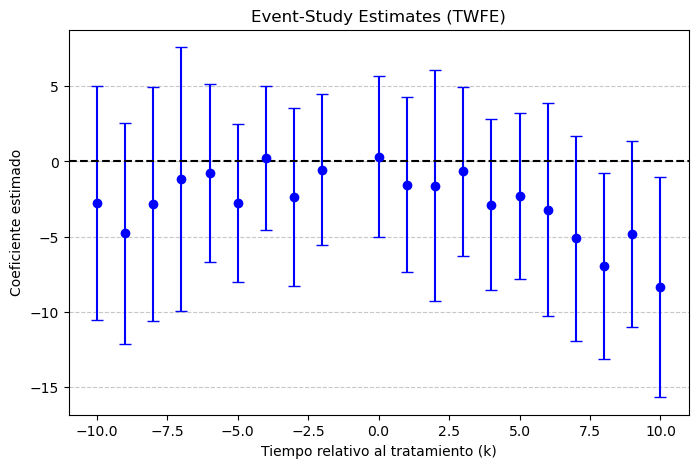

In [40]:
def parse_k(name):
    if "m" in name:
        return -int(name.split("m")[1])
    return int(name.split("_")[1])

coef_data['k'] = coef_data['variable'].apply(parse_k)
coef_data = coef_data.sort_values("k")

# --- 6. Plot Event-Study ---
plt.figure(figsize=(8,5))
plt.errorbar(coef_data['k'], coef_data['coef'], yerr=1.96*coef_data['se'], fmt='o', capsize=4, color='blue')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel("Tiempo relativo al tratamiento (k)")
plt.ylabel("Coeficiente estimado")
plt.title("Event-Study Estimates (TWFE)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [32]:
# --- 1. Calcular IC 95% ---
coef_data['ci_lower'] = coef_data['coef'] - 1.96 * coef_data['se']
coef_data['ci_upper'] = coef_data['coef'] + 1.96 * coef_data['se']

event_table = coef_data[['k', 'coef', 'se', 'ci_lower', 'ci_upper']].sort_values('k')

print(event_table.to_string(index=False))


 k      coef       se   ci_lower  ci_upper
-5 -2.471269 3.194833  -8.733142  3.790604
-4  0.195305 2.441000  -4.589056  4.979665
-3 -2.356086 2.994522  -8.225350  3.513177
-2 -0.546695 2.555817  -5.556097  4.462707
 0  0.300080 2.736932  -5.064307  5.664467
 1 -1.704920 2.958475  -7.503531  4.093690
 2 -1.835219 3.902182  -9.483497  5.813058
 3 -1.016772 2.904239  -6.709080  4.675537
 4 -3.249975 2.907948  -8.949553  2.449603
 5 -6.450250 3.310298 -12.938434  0.037933
